In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools

# Set style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

In [6]:
def load_data():
    # Determine directory relative to this script
    script_dir = os.path.dirname(os.getcwd())
    metrics_dir = os.path.join(script_dir,"metrics")
    
    adapt = [0, 120, 20, 2]
    test_ds_b4 = False
    
    combined_results = []
    
    print(f"Loading metrics from: {metrics_dir}")
    
    for a in adapt:
        if test_ds_b4:
            identifier = f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
        else:
            identifier = f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
            
        filename = f"channel_metrics_by_network_{identifier}.csv"
        path = os.path.join(metrics_dir, filename)
        
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["Adapt"] = a
            combined_results.append(df)
            print(f"Loaded: {filename}")
        else:
            print(f"Missing: {filename}")
            
    if combined_results:
        return pd.concat(combined_results, ignore_index=True)
    else:
        return pd.DataFrame()

In [8]:
df = load_data()
    
if df.empty:
    print("No data loaded.")

print(f"Total rows loaded: {len(df)}")

# 2. Filter for Channel 1
# Note: Ensure 'Channel' column exists and 1 is the correct identifier
if "Channel" in df.columns:
    df_ch1 = df[df["Channel"] == 1].copy()
    print(f"Rows after filtering for Channel 1: {len(df_ch1)}")
else:
    print("Column 'Channel' not found. Using all data.")
    df_ch1 = df

Loading metrics from: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\eval\live_results\metrics
Loaded: channel_metrics_by_network_30000_1000_100.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable120.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable20.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable2.csv
Total rows loaded: 1536
Rows after filtering for Channel 1: 192


In [10]:
# 3. Print Summary
print("\n--- Summary by Adapt (Channel 1) ---")
summary = df_ch1.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3)
print(summary)


--- Summary by Adapt (Channel 1) ---
          F1  Precision  Recall      TP       FP      FN
Adapt                                                   
0      0.569      0.482   0.815  93.750  140.458  20.750
2      0.654      0.627   0.740  82.312   67.250  32.188
20     0.643      0.592   0.762  86.958   77.562  27.542
120    0.637      0.585   0.766  86.625   79.917  27.875


In [11]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)


C:\Users\NCN\AppData\Local\Temp\ipykernel_29608\971360229.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


N=48 matched samples for statistics.
0 vs 120: p=0.0000
0 vs 20: p=0.0000
0 vs 2: p=0.0000
120 vs 2: p=0.0400


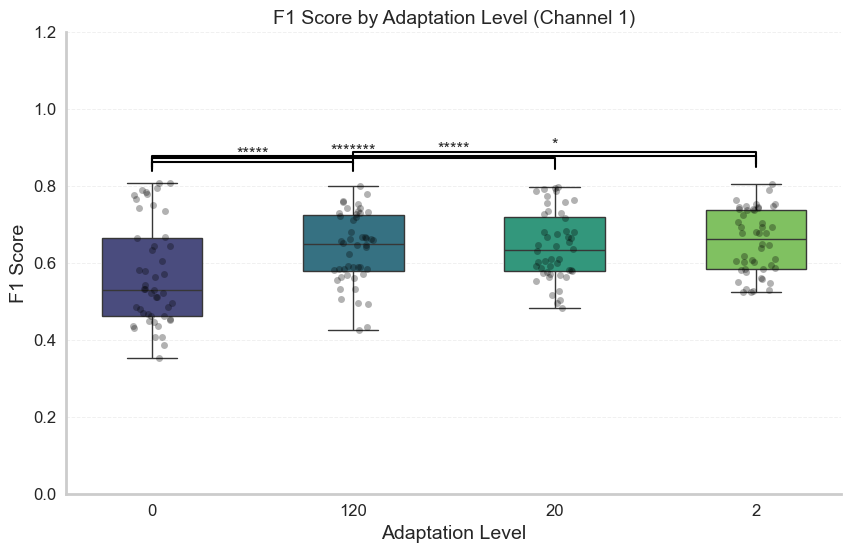

In [12]:
def plot_f1_boxplot_by_adapt(df, metric="F1"):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Adapt", y=metric, data=df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    # Pivot using Dataset and Network as identifiers for paired comparison
    pivot_cols = ["Dataset", "Network"]
    
    # Check if we have duplicates (e.g. multiple networks)
    # If multiple networks, we might need to include Network in pivot or average
    # The provided dataframe has 'Network', 'Dataset', 'Channel'. 
    # Since we filtered for Channel 1, 'Dataset' and 'Network' should be unique per Adapt level 
    # UNLESS there are multiple runs.
    
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            if a1 not in pivot.columns or a2 not in pivot.columns:
                continue

            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Adaptation Level (Channel 1)",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()


plot_f1_boxplot_by_adapt(df_ch1, "F1")
 

C:\Users\NCN\AppData\Local\Temp\ipykernel_29608\3660879890.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", inner="quartile", cut=0, order=adapt_values)


0 vs 120: p=0.0000
0 vs 20: p=0.0000
0 vs 2: p=0.0000
120 vs 2: p=0.0400


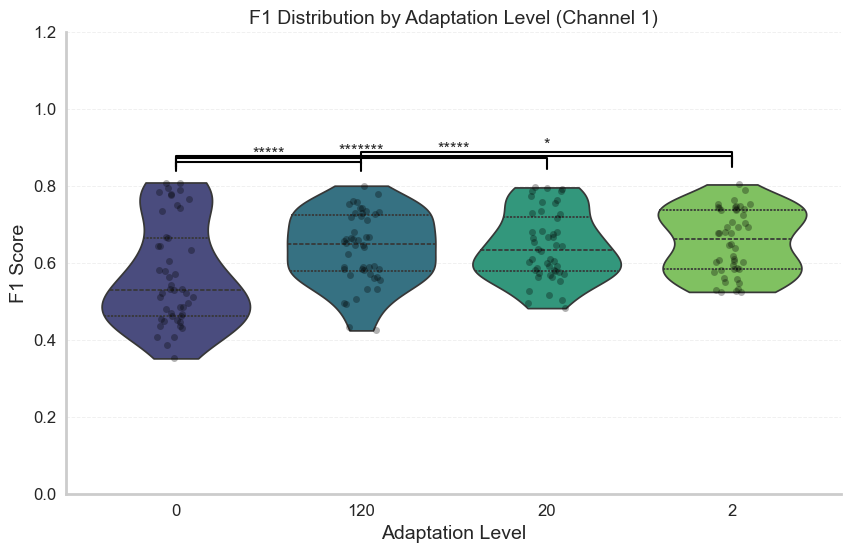

In [13]:
def plot_f1_violin_by_adapt(df, metric="F1"):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Violin plot
    sns.violinplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y=metric, data=df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    pivot_cols = ["Dataset", "Network"]
    
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            if a1 not in pivot.columns or a2 not in pivot.columns:
                continue

            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Distribution by Adaptation Level (Channel 1)",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

plot_f1_violin_by_adapt(df_ch1, "F1")

In [ ]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    adapt_values = sorted(df["Adapt"].unique())
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Adapt"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Adapt {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Adapt {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall (Channel 1)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_precision_recall(df_ch1)

    
